<a href="https://colab.research.google.com/github/whunotexplain/data_nba_players_analyze/blob/main/data_nba_players.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1)Library and color import

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#14141f',
    'axes.edgecolor':   '#2a2a3a',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'text.color':       '#eeeeee',
    'grid.color':       '#1e1e2e',
})

COLORS = ['#FFD700','#00B4D8','#57EE9A','#E63946','#C77DFF','#FF6B6B']

##2)Dataset

In [11]:
data = pd.read_csv('/content/sample_data/nba_player_stats_2026.csv')


In [12]:
data.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,290,461,130,55,171,151,1980,1893,2.70,0.76


In [13]:
print(f"Shape = {data.shape}")

Shape = (582, 28)


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PLAYER_ID  582 non-null    int64  
 1   RANK       582 non-null    int64  
 2   PLAYER     582 non-null    object 
 3   TEAM_ID    582 non-null    int64  
 4   TEAM       582 non-null    object 
 5   GP         582 non-null    int64  
 6   MIN        582 non-null    int64  
 7   FGM        582 non-null    int64  
 8   FGA        582 non-null    int64  
 9   FG_PCT     582 non-null    float64
 10  FG3M       582 non-null    int64  
 11  FG3A       582 non-null    int64  
 12  FG3_PCT    582 non-null    float64
 13  FTM        582 non-null    int64  
 14  FTA        582 non-null    int64  
 15  FT_PCT     582 non-null    float64
 16  OREB       582 non-null    int64  
 17  DREB       582 non-null    int64  
 18  REB        582 non-null    int64  
 19  AST        582 non-null    int64  
 20  STL       

In [15]:
data.describe()

,PLAYER_ID,RANK,TEAM_ID,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
count,5.820000e+02,582.000000,5.820000e+02,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,...,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,1.476871e+06,291.182131,1.610613e+09,45.792096,1019.788660,177.365979,376.561856,0.461811,56.214777,156.305842,...,185.005155,113.027491,35.589347,20.458763,58.309278,83.969072,488.651203,563.673540,1.874296,0.726873
std,4.499530e+05,167.881426,8.755817e+00,24.937300,771.976925,164.245561,341.038339,0.102732,59.396653,155.982454,...,167.263286,121.804996,30.195315,24.895393,54.955127,61.869741,459.775808,501.760652,0.990909,0.544475
min,2.544000e+03,1.000000,1.610613e+09,1.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,0.000000,0.000000
25%,1.629018e+06,146.250000,1.610613e+09,23.000000,293.250000,38.000000,91.500000,0.417000,6.000000,21.500000,...,49.000000,21.250000,9.000000,4.000000,14.000000,27.000000,107.000000,133.250000,1.262500,0.400000
50%,1.630694e+06,291.000000,1.610613e+09,51.000000,940.500000,135.000000,292.000000,0.456000,38.000000,114.500000,...,148.500000,78.500000,30.000000,11.000000,42.500000,78.000000,363.500000,458.500000,1.725000,0.625000
75%,1.641838e+06,436.750000,1.610613e+09,67.750000,1609.250000,267.500000,579.250000,0.505750,89.750000,245.750000,...,275.750000,151.750000,55.000000,28.000000,85.000000,131.000000,759.000000,873.000000,2.320000,0.930000
max,1.643257e+06,579.000000,1.610613e+09,82.000000,2953.000000,736.000000,1543.000000,0.833000,273.000000,740.000000,...,892.000000,697.000000,150.000000,197.000000,259.000000,267.000000,2143.000000,2665.000000,6.360000,5.000000


In [16]:
data.dtypes.to_list()

[dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64')]

Добавил колонку для просмотра действий в среднем за игру

In [17]:
per_game_columns = ['PTS','REB','AST','STL','BLK','TOV','FGA','FGM','FG3A','FG3M','FTA','FTM']
for col in per_game_columns:
  data[col + "_PG"] = data[col] / data['GP']

##3.EDA

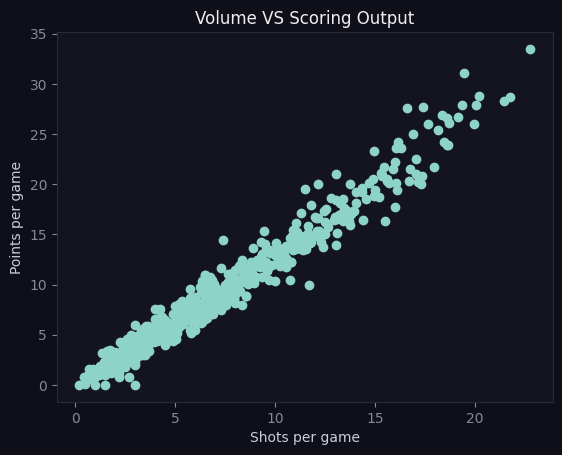

In [18]:
plt.scatter(data['FGA_PG'], data['PTS_PG'])
plt.xlabel("Shots per game")
plt.ylabel("Points per game")
plt.title("Volume VS Scoring Output")
plt.show()

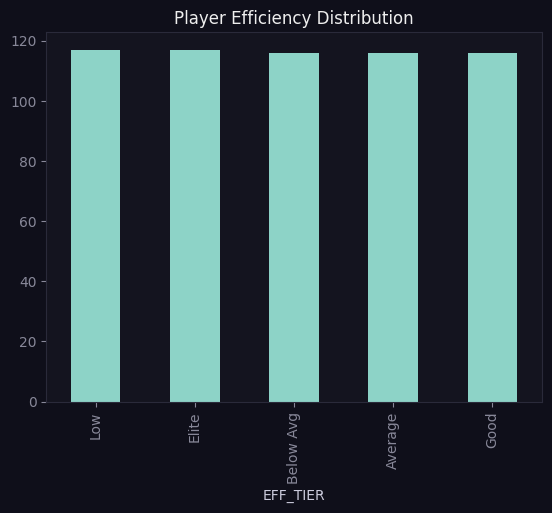

In [20]:
#Advanced ratio
data['PTS_per_FGA'] = data['PTS'] / data['FGA']
data["THREE_RATE"] = data["FG3A"] / data['FGA']
data['FTA_RATE'] = data['FTA'] / data['FGA']
data['EFF_PER_MIN'] = data['EFF'] / data['MIN']

data['EFF_TIER'] = pd.qcut(data['EFF'], q=5, labels = ['Low','Below Avg','Average','Good','Elite'])

data['EFF_TIER'].value_counts().plot(kind='bar')
plt.title("Player Efficiency Distribution")
plt.show()

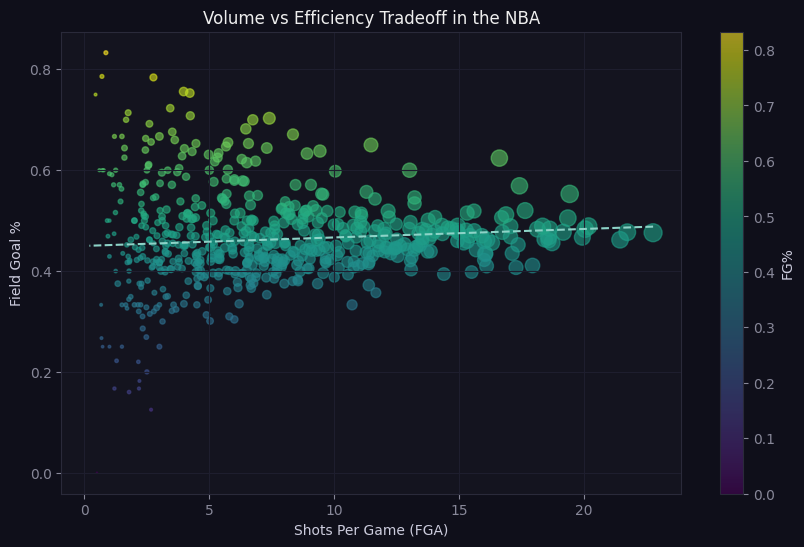

In [21]:
plt.figure(figsize=(10,6))


scatter= plt.scatter(
    data['FGA_PG'],
    data['FG_PCT'],
    s=data['PTS_PG']*5,
    c=data['FG_PCT'],
    alpha=0.6
)

# Trend line
z = np.polyfit(data['FGA_PG'], data['FG_PCT'], 1)
p = np.poly1d(z)
plt.plot(data['FGA_PG'], p(data['FGA_PG']), linestyle="--")

plt.xlabel("Shots Per Game (FGA)")
plt.ylabel("Field Goal %")
plt.title("Volume vs Efficiency Tradeoff in the NBA")

plt.colorbar(scatter, label="FG%")
plt.grid(True)

plt.show()

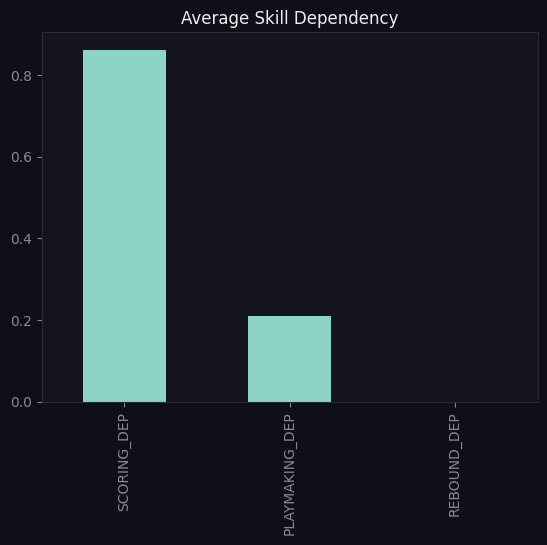

In [22]:
data['SCORING_DEP'] = data['PTS'] / data['EFF']
data['PLAYMAKING_DEP'] = data['AST'] / data['EFF']
data['REBOUND_DEP'] = data['REB'] / data['EFF']

data[['SCORING_DEP','PLAYMAKING_DEP','REBOUND_DEP']].mean().plot(kind='bar')
plt.title("Average Skill Dependency")
plt.show()

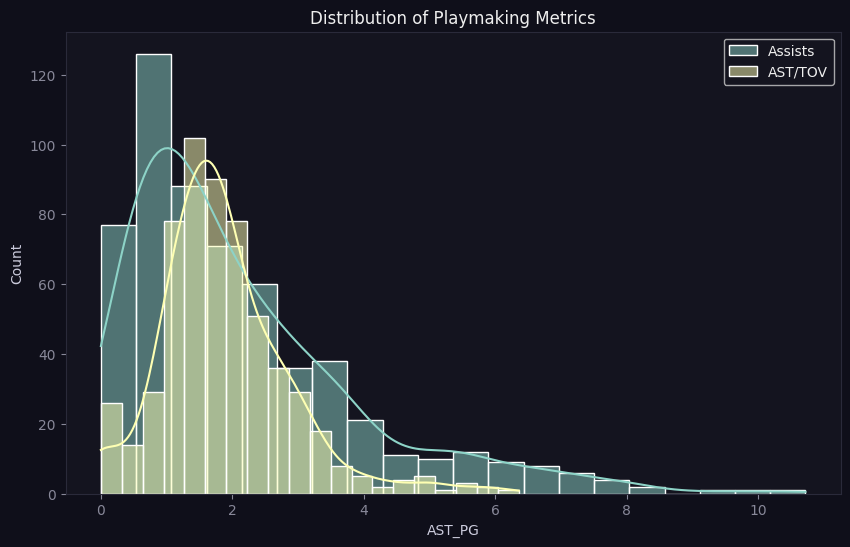

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data['AST_PG'],bins=20, kde=True, label="Assists")
sns.histplot(data['AST_TOV'], bins=20, kde=True, label="AST/TOV")

plt.legend()
plt.title("Distribution of Playmaking Metrics")
plt.show()